# Introduction

The aim of this project is to perform Exploratory Data Analysis (EDA) on the Titanic dataset. The analysis includes data inspection, cleaning, visualization, correlation analysis, and extracting insights that can support future machine learning models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)


In [3]:
titanic = pd.read_csv("Titanic-Dataset.csv")

In [4]:
titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
print("Titanic:", titanic.shape)

Titanic: (891, 12)


In [7]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
print(titanic.duplicated().sum())

0


In [9]:
# Summary:
# The Titanic dataset contains 891 passenger records and 12 features.
# It includes both numerical and categorical variables.
# Missing values are present in the Age, Cabin, and Embarked columns,
# while no duplicate records were found. Overall, the dataset is well-structured
# but requires cleaning to handle missing values before analysis.

# Data Cleaning

In [10]:
titanic_clean = titanic.copy()

In [11]:
# Fill Age
titanic_clean["Age"] = titanic_clean["Age"].fillna(
    titanic_clean["Age"].median()
)

# Fill Embarked
titanic_clean["Embarked"] = titanic_clean["Embarked"].fillna(
    titanic_clean["Embarked"].mode()[0]
)

# Drop Cabin
titanic_clean.drop(columns="Cabin", inplace=True)

# Remove duplicates
titanic_clean.drop_duplicates(inplace=True)

# Correct data types
categorical_columns = ["Survived", "Pclass"]

for col in categorical_columns:
    titanic_clean[col] = titanic_clean[col].astype("category")

In [12]:
# Verify data quality
print("\nTitanic Missing Values After Cleaning:")
print(titanic_clean.isnull().sum())

print("\nTitanic Duplicate Records:")
print(titanic_clean.duplicated().sum())


Titanic Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Titanic Duplicate Records:
0


In [22]:
# Data Cleaning Decisions:
# - Filled missing Age values with the median to reduce the effect of outliers.
# - Filled missing Embarked values with the mode since it is a categorical feature.
# - Dropped the Cabin column due to a high number of missing values.
# - No duplicated records were found.
# - Converted Survived and Pclass to the category data type for better interpretation.
# - Verified the cleaned dataset contained no unnecessary missing values or duplicates.

# Exploratory Data Analysis (EDA)

In [31]:
# Cleaned Dataset

titanic_clean.to_csv("Titanic_Cleaned.csv", index=False)

titanic = pd.read_csv("Titanic_Cleaned.csv")

titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Univariate Analysis

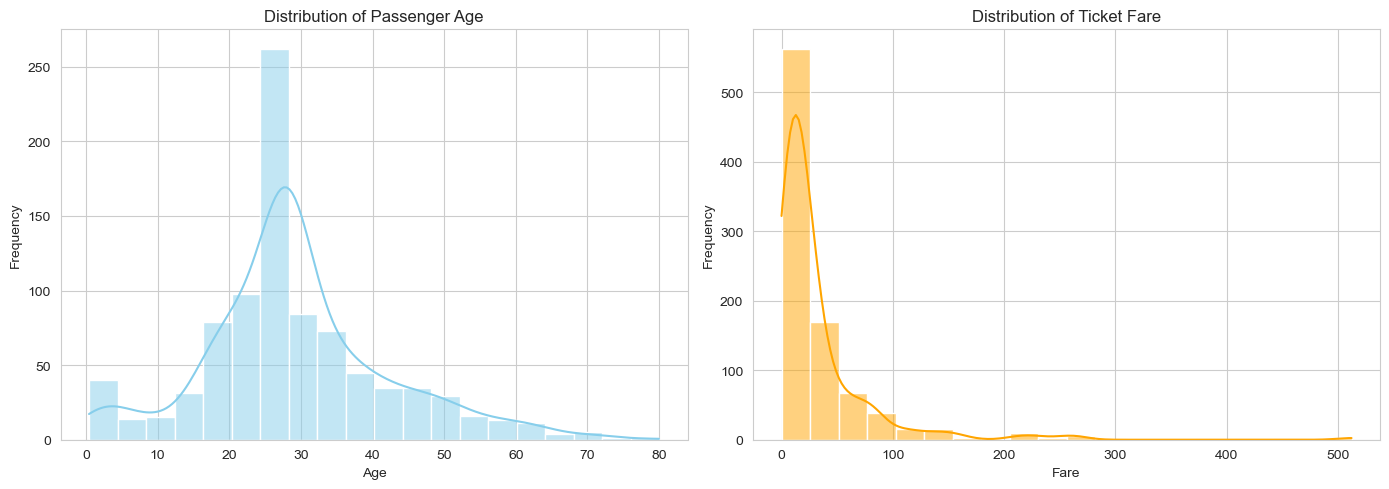

In [24]:
# Histogram showing Passenger age and Ticket Fare Distribution

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(
    data=titanic,
    x="Age",
    bins=20,
    kde=True,
    color="skyblue",
    ax=axes[0]
)

axes[0].set_title("Distribution of Passenger Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")


sns.histplot(
    data=titanic,
    x="Fare",
    bins=20,
    kde=True,
    color="orange",
    ax=axes[1]
)

axes[1].set_title("Distribution of Ticket Fare")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

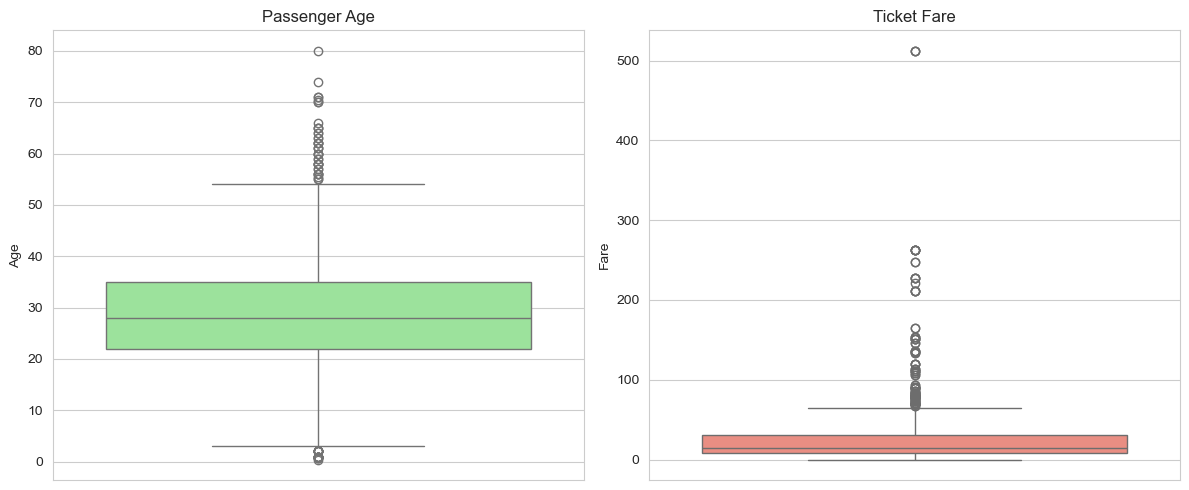

In [25]:
# Boxplot showing Passenger age and Ticket Fare 

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(
    y=titanic["Age"],
    color="lightgreen",
    ax=axes[0]
)

axes[0].set_title("Passenger Age")


sns.boxplot(
    y=titanic["Fare"],
    color="salmon",
    ax=axes[1]
)

axes[1].set_title("Ticket Fare")

plt.tight_layout()
plt.show()

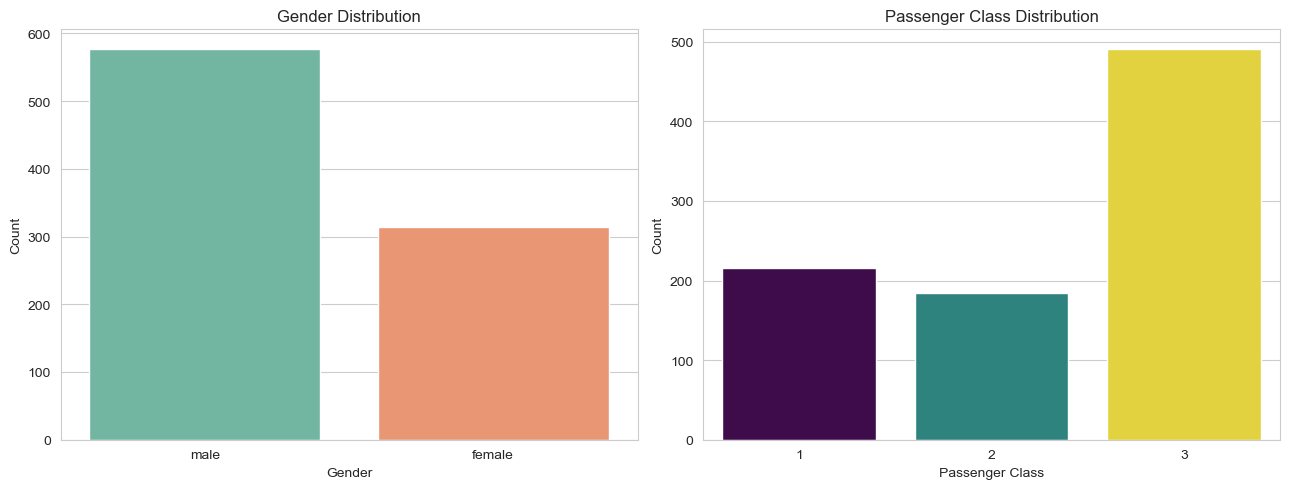

In [26]:
# Gender and Passenger Class Distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(
    data=titanic,
    x="Sex",
    hue="Sex",
    palette="Set2",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Gender Distribution")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")

sns.countplot(
    data=titanic,
    x="Pclass",
    hue="Pclass",
    palette="viridis",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Passenger Class Distribution")
axes[1].set_xlabel("Passenger Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
# Univariate Analysis Summary:
# - Fare has the highest variation (std = 49.69), indicating a wide range of ticket prices.
# - Outliers are present in the Fare distribution, while Age shows only a few outliers.
# - Most passengers were male and traveled in Third Class.
# - The median age is 28 years, indicating that most passengers were young adults.

### Bivariate Analysis

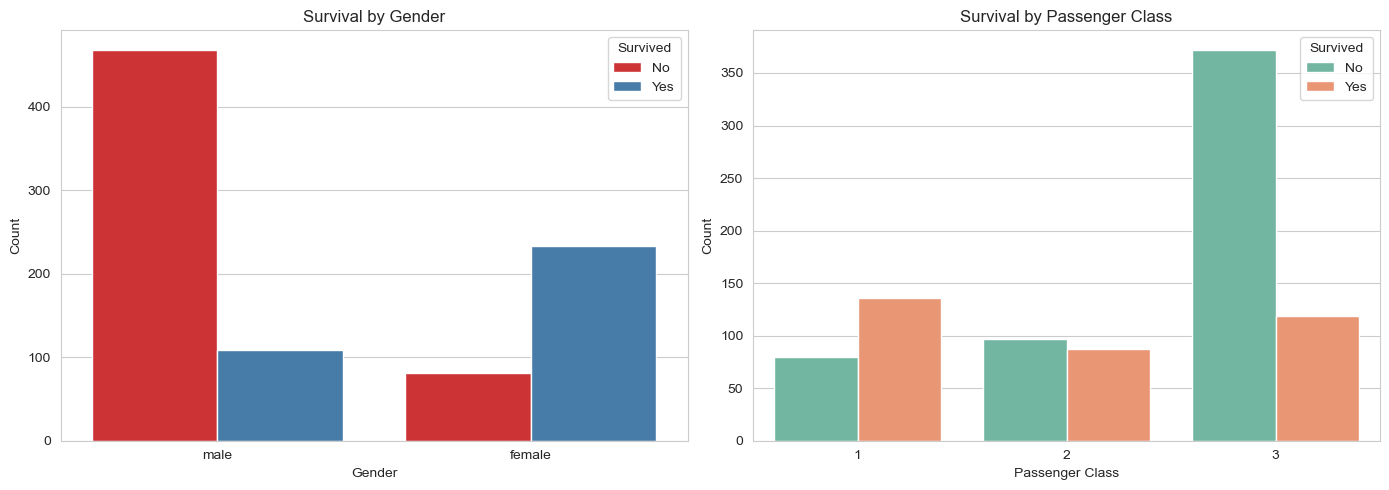

In [27]:
# Survival Analysis( SUrvival by Gender and Passenger Class

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=titanic,
    x="Sex",
    hue="Survived",
    palette="Set1",
    ax=axes[0]
)
axes[0].set_title("Survival by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")
axes[0].legend(title="Survived", labels=["No", "Yes"])

sns.countplot(
    data=titanic,
    x="Pclass",
    hue="Survived",
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Survival by Passenger Class")
axes[1].set_xlabel("Passenger Class")
axes[1].set_ylabel("Count")
axes[1].legend(title="Survived", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

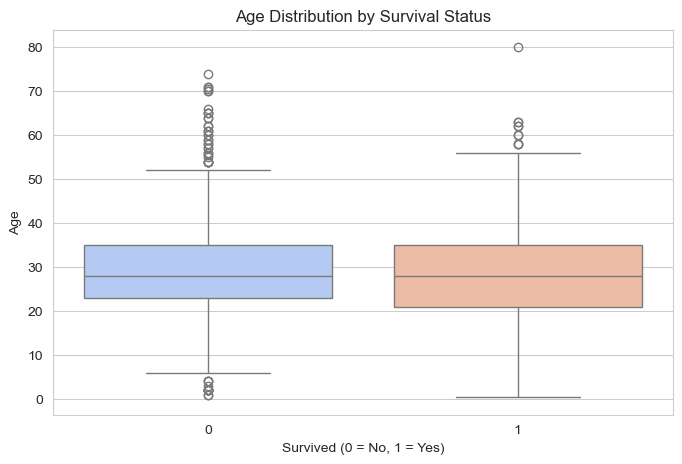

In [30]:
# Age vs Survival

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=titanic,
    x="Survived",
    y="Age",
    hue="Survived",
    palette="coolwarm",
    legend=False
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

In [ ]:
# Bivariate Analysis Summary:
# - Gender, Passenger Class, and Fare appear to have the greatest influence on survival.
# - Female and First-Class passengers had noticeably higher survival rates.
# - Age showed a weaker relationship with survival, with similar age distributions for survivors and non-survivors.

### Correlation and Feature Importance

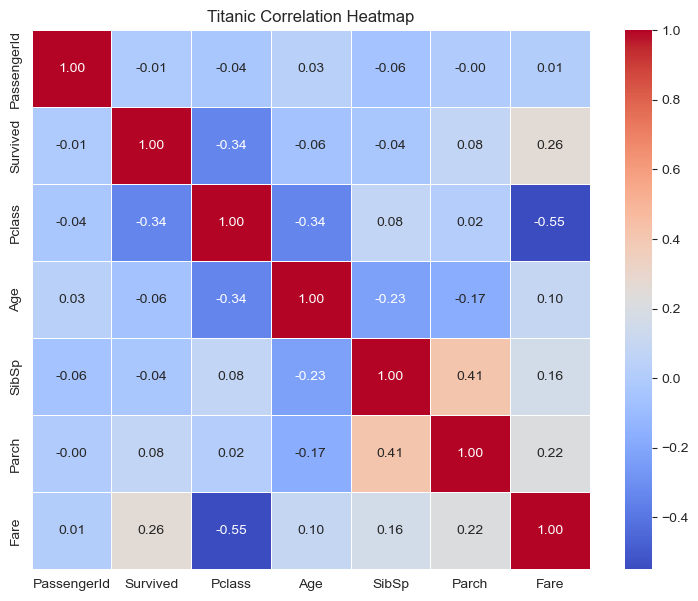

In [29]:
# Titanic Correlation Map

plt.figure(figsize=(9, 7))

sns.heatmap(
    titanic.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Titanic Correlation Heatmap")
plt.show()

In [21]:
# Pclass has the strongest negative relationship with survival.
# Fare has a moderate positive relationship with survival.
# PassengerId contributes little information and could be excluded from predictive models.